# Regions distribution

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path

In [2]:
path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [3]:
import Regions_functions_V2
from Regions_functions_V2 import polygon_N1, polygon_N2, polygon_N3, polygon_C1, polygon_S1, polygon_SP, polygon_S2, polygon_H1, polygon_J1, polygon_F1, polygon_HW1
from Regions_functions_V2 import polygon_lon_lat_N1, polygon_lon_lat_N2, polygon_lon_lat_N3, polygon_lon_lat_C1, polygon_lon_lat_S1, polygon_lon_lat_SP, polygon_lon_lat_S2, polygon_lon_lat_H1, polygon_lon_lat_J1, polygon_lon_lat_F1, polygon_lon_lat_HW1

In [ ]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc'
filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_2.nc'
data_y1 = xr.open_dataset(filename1).isel(obs=slice(2672, None))
#data_y2 = xr.open_dataset(filename2).isel(obs=slice(2672, None))

In [5]:
def volume_region_bottom(polygon):
    mesh = xr.open_dataset(path['mask'])
    volume = mesh['volume']
    mask = xr.open_dataset(path['mask'])['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 0
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [6]:
def polygon_definition_data(ds, region_polygon, status_input,  depth_min=0):
#
    lons = ds['lon'].values
    lats = ds['lat'].values
    depths = ds['z'].values
    statuses = ds['status'].values
    #
    points_flat = np.column_stack((lons.ravel(), lats.ravel()))
    poly_path = Path(region_polygon)
    # points inside polygon
    inside_mask_flat = poly_path.contains_points(points_flat)
    inside_mask = inside_mask_flat.reshape(lons.shape)
    # >= 50 mask
    deep_mask = depths >= depth_min
    #deep_mask = depths >= depth_min
    # Colloidal status 
    status_mask = np.isin(statuses, status_input) 
    #
    valid_mask = inside_mask & deep_mask & status_mask
    #
    counts = np.sum(valid_mask, axis=0) 
    #
    times = ds['time'].values
    time_index = np.nanmax(times, axis=0) 
    #
    return pd.DataFrame({'count': counts}, index=time_index)

In [7]:
def polygon_mean_depth_data(ds, region_polygon, status_input, depth_min=0):
    #
    lons = ds['lon'].values
    lats = ds['lat'].values
    depths = ds['z'].values
    statuses = ds['status'].values
    times = ds['time'].values

    points_flat = np.column_stack((lons.ravel(), lats.ravel()))
    poly_path = Path(region_polygon)
    inside_mask = poly_path.contains_points(points_flat).reshape(lons.shape)

    deep_mask = depths >= depth_min
    status_mask = np.isin(statuses, status_input)
    
    valid_mask = inside_mask & deep_mask & status_mask


    masked_depths = np.where(valid_mask, depths, np.nan)

    mean_depths = np.nanmean(masked_depths, axis=0)

    time_index = np.nanmax(times, axis=0) 

    return pd.DataFrame({'mean_depth': mean_depths}, index=time_index)

In [8]:
volume_N1 = volume_region_bottom(polygon_N1)
volume_N2 = volume_region_bottom(polygon_N2)
volume_N3 = volume_region_bottom(polygon_N3)
volume_C1 = volume_region_bottom(polygon_C1)
volume_S1 = volume_region_bottom(polygon_S1)
volume_SP = volume_region_bottom(polygon_SP)
volume_S2 = volume_region_bottom(polygon_S2)
volume_H1 = volume_region_bottom(polygon_H1)
volume_J1 = volume_region_bottom(polygon_J1)
volume_F1 = volume_region_bottom(polygon_F1)
volume_HW1 = volume_region_bottom(polygon_HW1)

Concentrations December 2007

In [ ]:
counts_N1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_N1, status_input=[1,2,3])
counts_N2w_y1= polygon_definition_data(data_y1, polygon_lon_lat_N2, status_input=[1,2,3])
counts_N3w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_N3, status_input=[1,2,3])
counts_C1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_C1, status_input=[1,2,3])
counts_S1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_S1, status_input=[1,2,3])
counts_SPw_y1 = polygon_definition_data(data_y1, polygon_lon_lat_SP, status_input=[1,2,3])
counts_S2w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_S2, status_input=[1,2,3])
counts_H1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_H1, status_input=[1,2,3])
counts_J1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_J1, status_input=[1,2,3])
counts_F1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_F1, status_input=[1,2,3])
counts_HW1w_y1 = polygon_definition_data(data_y1, polygon_lon_lat_HW1, status_input=[1,2,3])
#
concentration_N1w_y1 = np.sum(counts_N1w_y1) / volume_N1 / len(data_y1['obs'])
concentration_N2w_y1 = np.sum(counts_N2w_y1) / volume_N2 / len(data_y1['obs'])
concentration_N3w_y1 = np.sum(counts_N3w_y1) / volume_N3 / len(data_y1['obs'])
concentration_C1w_y1 = np.sum(counts_C1w_y1) / volume_C1 / len(data_y1['obs'])
concentration_S1w_y1 = np.sum(counts_S1w_y1) / volume_S1 / len(data_y1['obs'])
concentration_SPw_y1 = np.sum(counts_SPw_y1) / volume_SP / len(data_y1['obs'])
concentration_S2w_y1 = np.sum(counts_S2w_y1) / volume_S2 / len(data_y1['obs'])
concentration_H1w_y1 = np.sum(counts_H1w_y1) / volume_H1 / len(data_y1['obs'])
concentration_J1w_y1 = np.sum(counts_J1w_y1) / volume_J1 / len(data_y1['obs'])
concentration_F1w_y1 = np.sum(counts_F1w_y1) / volume_F1 / len(data_y1['obs'])
concentration_HW1w_y1 = np.sum(counts_HW1w_y1) / volume_HW1 / len(data_y1['obs'])

/home/vvalenzuela/conda_envs/Parcels/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [ ]:
counts_N1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_N1, status_input=[11,12,13])
counts_N2s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_N2, status_input=[11,12,13])
counts_N3s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_N3, status_input=[11,12,13])
counts_C1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_C1, status_input=[11,12,13])
counts_S1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_S1, status_input=[11,12,13])
counts_SPs_y1 = polygon_definition_data(data_y1, polygon_lon_lat_SP, status_input=[11,12,13])
counts_S2s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_S2, status_input=[11,12,13])
counts_H1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_H1, status_input=[11,12,13])
counts_J1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_J1, status_input=[11,12,13])
counts_F1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_F1, status_input=[11,12,13])
counts_HW1s_y1 = polygon_definition_data(data_y1, polygon_lon_lat_HW1, status_input=[11,12,13])
#
concentration_N1s_y1 = np.sum(counts_N1s_y1) / volume_N1 / len(data_y1['obs'])
concentration_N2s_y1 = np.sum(counts_N2s_y1) / volume_N2 / len(data_y1['obs'])
concentration_N3s_y1 = np.sum(counts_N3s_y1) / volume_N3 / len(data_y1['obs'])
concentration_C1s_y1 = np.sum(counts_C1s_y1) / volume_C1 / len(data_y1['obs'])
concentration_S1s_y1 = np.sum(counts_S1s_y1) / volume_S1 / len(data_y1['obs'])
concentration_SPs_y1 = np.sum(counts_SPs_y1) / volume_SP / len(data_y1['obs'])
concentration_S2s_y1 = np.sum(counts_S2s_y1) / volume_S2 / len(data_y1['obs'])
concentration_H1s_y1 = np.sum(counts_H1s_y1) / volume_H1 / len(data_y1['obs'])
concentration_J1s_y1 = np.sum(counts_J1s_y1) / volume_J1 / len(data_y1['obs'])
concentration_F1s_y1 = np.sum(counts_F1s_y1) / volume_F1 / len(data_y1['obs'])
concentration_HW1s_y1 = np.sum(counts_HW1s_y1) / volume_HW1 / len(data_y1['obs'])

Concentrations December 2008

In [ ]:
#counts_N1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_N1, status_input=[1,2,3])
#counts_N2w_y2= polygon_definition_data(data_y2, polygon_lon_lat_N2, status_input=[1,2,3])
#counts_N3w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_N3, status_input=[1,2,3])
#counts_C1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_C1, status_input=[1,2,3])
#counts_S1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_S1, status_input=[1,2,3])
#counts_SPw_y2 = polygon_definition_data(data_y2, polygon_lon_lat_SP, status_input=[1,2,3])
#counts_S2w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_S2, status_input=[1,2,3])
#counts_H1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_H1, status_input=[1,2,3])
#counts_J1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_J1, status_input=[1,2,3])
#counts_F1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_F1, status_input=[1,2,3])
#counts_HW1w_y2 = polygon_definition_data(data_y2, polygon_lon_lat_HW1, status_input=[1,2,3])
#
#concentration_N1w_y2 = np.sum(counts_N1w_y2) / volume_N1 / len(data_y2['obs'])
#concentration_N2w_y2 = np.sum(counts_N2w_y2) / volume_N2 / len(data_y2['obs'])
#concentration_N3w_y2 = np.sum(counts_N3w_y2) / volume_N3 / len(data_y2['obs'])
#concentration_C1w_y2 = np.sum(counts_C1w_y2) / volume_C1 / len(data_y2['obs'])
#concentration_S1w_y2 = np.sum(counts_S1w_y2) / volume_S1 / len(data_y2['obs'])
#concentration_SPw_y2 = np.sum(counts_SPw_y2) / volume_SP / len(data_y2['obs'])
#concentration_S2w_y2 = np.sum(counts_S2w_y2) / volume_S2 / len(data_y2['obs'])
#concentration_H1w_y2 = np.sum(counts_H1w_y2) / volume_H1 / len(data_y2['obs'])
#concentration_J1w_y2 = np.sum(counts_J1w_y2) / volume_J1 / len(data_y2['obs'])
#concentration_F1w_y2 = np.sum(counts_F1w_y2) / volume_F1 / len(data_y2['obs'])
#concentration_HW1w_y2 = np.sum(counts_HW1w_y2) / volume_HW1 / len(data_y2['obs'])

In [ ]:
#counts_N1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_N1, status_input=[11,12,13])
#counts_N2s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_N2, status_input=[11,12,13])
#counts_N3s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_N3, status_input=[11,12,13])
#counts_C1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_C1, status_input=[11,12,13])
#counts_S1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_S1, status_input=[11,12,13])
#counts_SPs_y2 = polygon_definition_data(data_y2, polygon_lon_lat_SP, status_input=[11,12,13])
#counts_S2s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_S2, status_input=[11,12,13])
#counts_H1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_H1, status_input=[11,12,13])
#counts_J1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_J1, status_input=[11,12,13])
#counts_F1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_F1, status_input=[11,12,13])
#counts_HW1s_y2 = polygon_definition_data(data_y2, polygon_lon_lat_HW1, status_input=[11,12,13])
#
#concentration_N1s_y2 = np.sum(counts_N1s_y2) / volume_N1 / len(data_y2['obs'])
#concentration_N2s_y2 = np.sum(counts_N2s_y2) / volume_N2 / len(data_y2['obs'])
#concentration_N3s_y2 = np.sum(counts_N3s_y2) / volume_N3 / len(data_y2['obs'])
#concentration_C1s_y2 = np.sum(counts_C1s_y2) / volume_C1 / len(data_y2['obs'])
#concentration_S1s_y2 = np.sum(counts_S1s_y2) / volume_S1 / len(data_y2['obs'])
#concentration_SPs_y2 = np.sum(counts_SPs_y2) / volume_SP / len(data_y2['obs'])
#concentration_S2s_y2 = np.sum(counts_S2s_y2) / volume_S2 / len(data_y2['obs'])
#concentration_H1s_y2 = np.sum(counts_H1s_y2) / volume_H1 / len(data_y2['obs'])
#concentration_J1s_y2 = np.sum(counts_J1s_y2) / volume_J1 / len(data_y2['obs'])
#concentration_F1s_y2 = np.sum(counts_F1s_y2) / volume_F1 / len(data_y2['obs'])
#concentration_HW1s_y2 = np.sum(counts_HW1s_y2) / volume_HW1 / len(data_y2['obs'])

In [ ]:
md_N1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_N1, status_input=[1,2,3]))
md_N2w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_N2, status_input=[1,2,3]))
md_N3w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_N3, status_input=[1,2,3]))
md_C1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_C1, status_input=[1,2,3]))
md_S1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_S1, status_input=[1,2,3]))
md_SPw = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_SP, status_input=[1,2,3]))
md_S2w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_S2, status_input=[1,2,3]))
md_H1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_H1, status_input=[1,2,3]))
md_J1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_J1, status_input=[1,2,3]))
md_F1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_F1, status_input=[1,2,3]))
md_HW1w = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_HW1, status_input=[1,2,3]))

/tmp/ipykernel_3529761/1002182718.py:21: RuntimeWarning: Mean of empty slice
  mean_depths = np.nanmean(masked_depths, axis=0)


In [ ]:
md_N1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_N1, status_input=[11,12,13]))
md_N2s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_N2, status_input=[11,12,13]))
md_N3s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_N3, status_input=[11,12,13]))
md_C1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_C1, status_input=[11,12,13]))
md_S1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_S1, status_input=[11,12,13]))
md_SPs = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_SP, status_input=[11,12,13]))
md_S2s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_S2, status_input=[11,12,13]))
md_H1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_H1, status_input=[11,12,13]))
md_J1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_J1, status_input=[11,12,13]))
md_F1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_F1, status_input=[11,12,13]))
md_HW1s = np.nanmedian(polygon_mean_depth_data(data_y1, polygon_lon_lat_HW1, status_input=[11,12,13]))

/tmp/ipykernel_3529761/1002182718.py:21: RuntimeWarning: Mean of empty slice
  mean_depths = np.nanmean(masked_depths, axis=0)
/tmp/ipykernel_3529761/2822244026.py:9: RuntimeWarning: All-NaN slice encountered
  md_J1s = np.nanmedian(polygon_mean_depth_data(data, polygon_lon_lat_J1, status_input=[11,12,13]))


In [13]:
regions = ['N1', 'N2', 'N3', 'C1', 'S1', 'SP', 'HW1', 'F1', 'S2', 'H1', 'J1']

In [ ]:
concentrations_W = np.array([concentration_N1w_y1[0], concentration_N2w_y1[0], concentration_N3w_y1[0], concentration_C1w_y1[0], concentration_S1w_y1[0]
                             , concentration_SPw_y1[0], concentration_HW1w_y1[0], concentration_F1w_y1[0], concentration_S2w_y1[0], concentration_H1w_y1[0] 
                             , concentration_J1w_y1[0]])

/tmp/ipykernel_3529761/2975508528.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  concentrations_W = np.array([concentration_N1w[0], concentration_N2w[0], concentration_N3w[0], concentration_C1w[0], concentration_S1w[0]
/tmp/ipykernel_3529761/2975508528.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  , concentration_SPw[0], concentration_HW1w[0], concentration_F1w[0], concentration_S2w[0], concentration_H1w[0]
/tmp/ipykernel_3529761/2975508528.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Da

In [ ]:
concentrations_S = np.array([concentration_N1s_y1[0], concentration_N2s_y1[0], concentration_N3s_y1[0], concentration_C1s_y1[0], concentration_S1s_y1[0]
                             , concentration_SPs_y1[0], concentration_HW1s_y1[0], concentration_F1s_y1[0], concentration_S2s_y1[0], concentration_H1s_y1[0] 
                             , concentration_J1s_y1[0]])

/tmp/ipykernel_3529761/4253227424.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  concentrations_S = np.array([concentration_N1s[0], concentration_N2s[0], concentration_N3s[0], concentration_C1s[0], concentration_S1s[0]
/tmp/ipykernel_3529761/4253227424.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  , concentration_SPs[0], concentration_HW1s[0], concentration_F1s[0], concentration_S2s[0], concentration_H1s[0]
/tmp/ipykernel_3529761/4253227424.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Da

In [16]:
median_W = np.array([md_N1w, md_N2w, md_N3w, md_C1w, md_S1w, md_SPw, md_HW1w, md_F1w, md_S2w, md_H1w, md_J1w])
median_S = np.array([md_N1s, md_N2s, md_N3s, md_C1s, md_S1s, md_SPs, md_HW1s, md_F1s, md_S2s, md_H1s, md_J1s])

In [17]:
colors_regions = ['r', 'b', 'tab:purple', 'c', 'g','m', 'tab:gray','tab:brown', 'tab:orange', 'y', 'tab:pink']

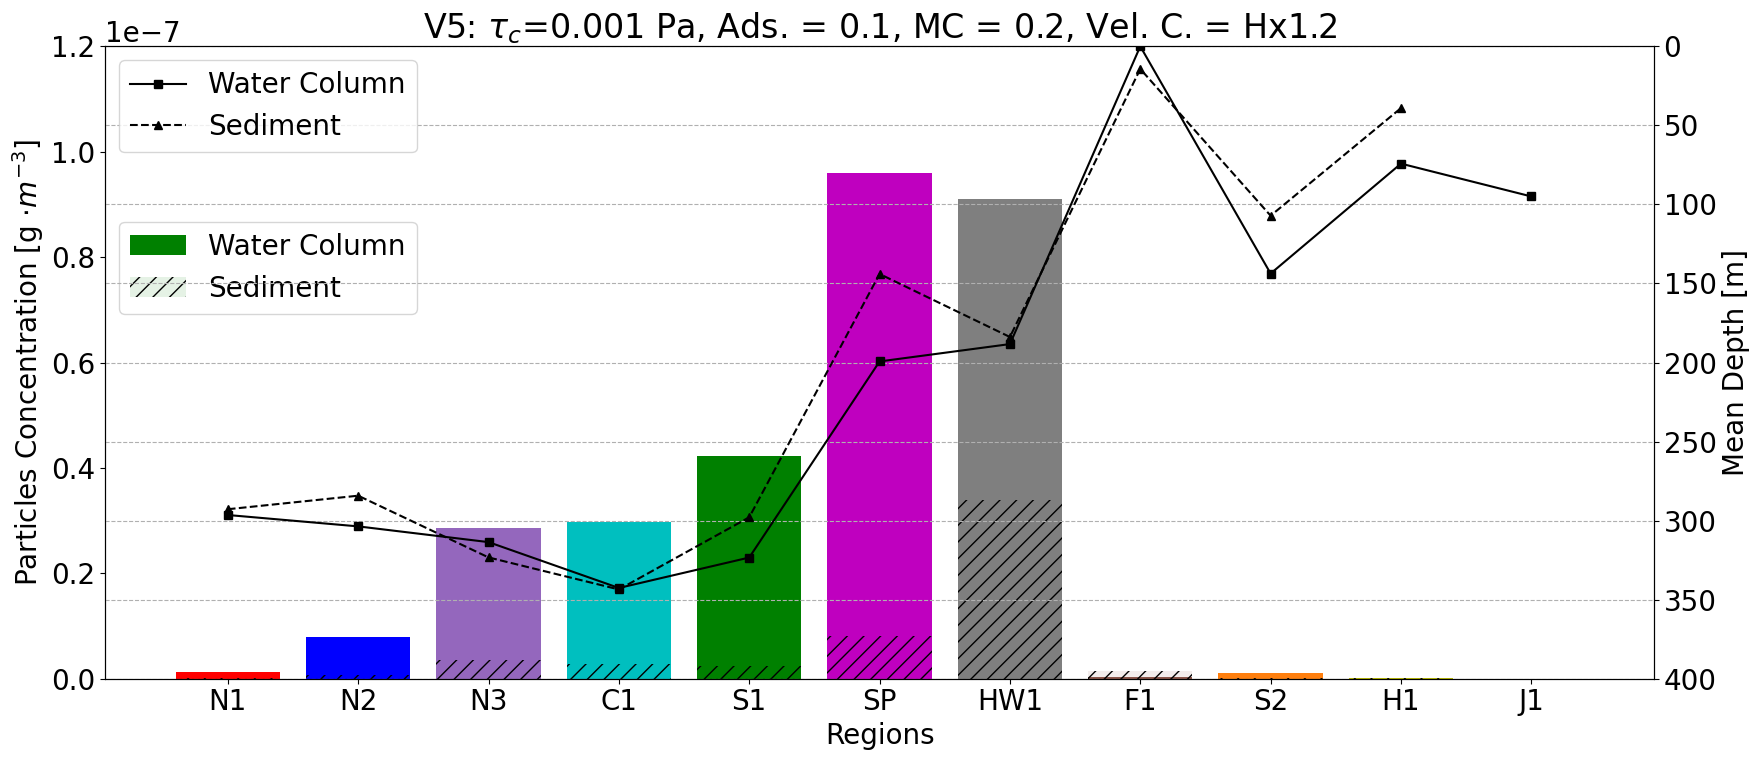

In [18]:
plt.rcParams.update({'font.size': 20})
fig, axis = plt.subplots(figsize = (18,8))
#

ax = axis.twinx()
# Water column
axis.bar(regions, concentrations_W, color = colors_regions) 
axis.bar(regions, concentrations_S, color = colors_regions, hatch='//', alpha = .1) 
#
axis.bar(regions[4], concentrations_W[4], color = colors_regions[4], label = 'Water Column') 
axis.bar(regions[4], concentrations_S[4], color = colors_regions[4], hatch='//', alpha = .1, label = 'Sediment') 
#
axis.set_ylabel(r'Particles Concentration [g $\cdot m^{-3}$]')

#axis.grid()
axis.legend(loc = 'center left', bbox_to_anchor=(0, .65))
axis.set_xlabel('Regions') 
ax.plot(regions,median_W, 's-k', label ='Water Column')   
ax.plot(regions,median_S, '^--k', label = 'Sediment') 
ax.invert_yaxis() 
#
ax.legend(loc = 'upper left')
ax.grid(linestyle = '--')
ax.set_ylabel('Mean Depth [m]')
ax.set_title(r'V5: $\tau_c$=0.001 Pa, Ads. = 0.1, MC = 0.2, Vel. C. = Hx1.2')
axis.set_ylim([0,1.2e-7])
ax.set_ylim([400,0])
plt.tight_layout()

In [19]:
mask['tmask'][0,0]

<xarray.DataArray 'tmask' (y: 898, x: 398)> Size: 357kB
[357404 values with dtype=int8]
Dimensions without coordinates: y, x

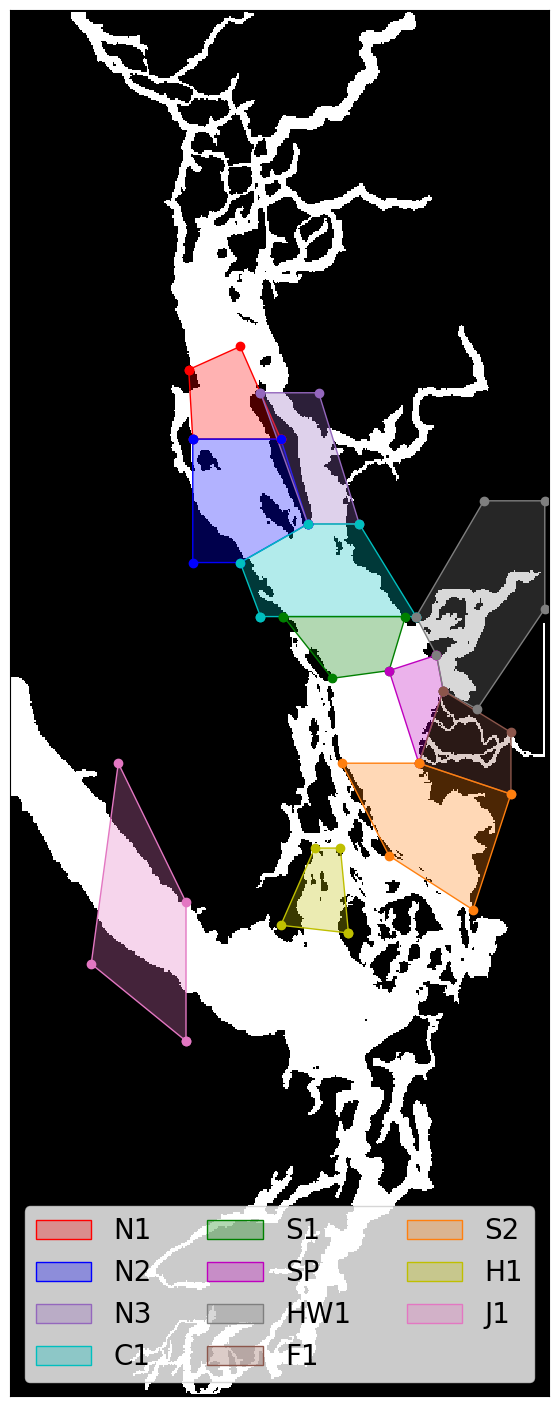

In [20]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
fig, ax = plt.subplots(figsize = (14,18))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
plot_polygon(polygon_N1, ax = ax, color = colors_regions[0], label = regions[0])
plot_polygon(polygon_N2, ax = ax, color = colors_regions[1], label = regions[1])
plot_polygon(polygon_N3, ax = ax, color = colors_regions[2], label = regions[2])
plot_polygon(polygon_C1, ax = ax, color = colors_regions[3], label = regions[3])
plot_polygon(polygon_S1, ax = ax, color = colors_regions[4], label = regions[4])
plot_polygon(polygon_SP, ax = ax, color = colors_regions[5], label = regions[5])
plot_polygon(polygon_HW1, ax = ax, color = colors_regions[6], label = regions[6])
plot_polygon(polygon_F1, ax = ax, color = colors_regions[7], label = regions[7])
plot_polygon(polygon_S2, ax = ax, color = colors_regions[8], label = regions[8])
plot_polygon(polygon_H1, ax = ax, color = colors_regions[9], label = regions[9])
plot_polygon(polygon_J1, ax = ax, color = colors_regions[10], label = regions[10])
ax.set_aspect(1.14)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc = 'lower center', ncol = 3)  

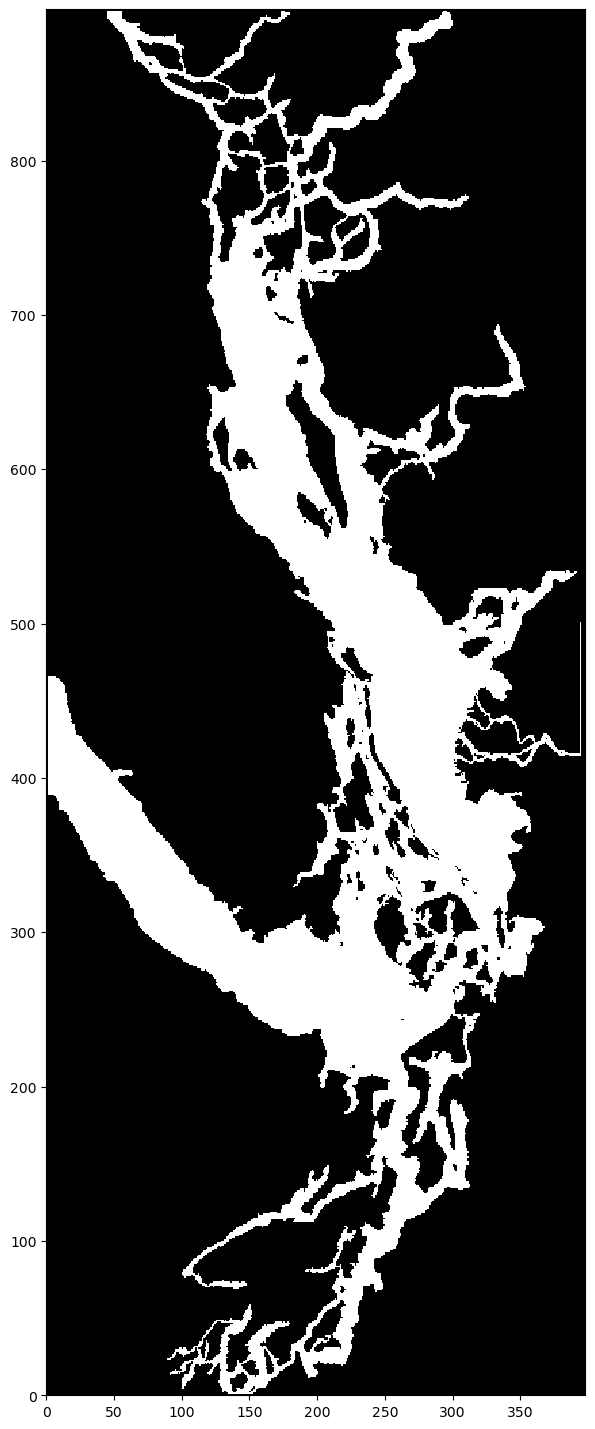

In [4]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
fig, ax = plt.subplots(figsize = (14,18))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
ax.set_aspect(1.14)
